# Evaluation CNN per FER-2013

Questo notebook valuta un modello salvato in `experiments/`.
Di default seleziona l'esperimento completo piu' recente, ma si puo' impostare manualmente `EXPERIMENT_NAME`.

Le figure, le tabelle e le predizioni vengono esportate in `results/`.


In [1]:
from pathlib import Path
from time import perf_counter
from datetime import datetime
from contextlib import contextmanager
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


def log_step(message):
    now = datetime.now().strftime("%H:%M:%S")
    print(f"[{now}] {message}", flush=True)


@contextmanager
def timed_step(name):
    start_time = perf_counter()
    log_step(f"INIZIO - {name}")
    try:
        yield
    finally:
        elapsed = perf_counter() - start_time
        log_step(f"FINE - {name} ({elapsed:.1f}s)")


SEED = 42
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 32

log_step(f"TensorFlow: {tf.__version__}")
log_step(f"GPU disponibili: {tf.config.list_physical_devices('GPU')}")


[12:28:58] TensorFlow: 2.21.0
[12:28:58] GPU disponibili: []


In [2]:
with timed_step("Configurazione percorsi evaluation"):
    current_dir = Path.cwd()
    project_root = current_dir if (current_dir / "data").exists() else current_dir.parent

    experiments_root = project_root / "experiments"
    results_root = project_root / "results"
    results_figures_dir = results_root / "figures"
    results_tables_dir = results_root / "tables"
    results_predictions_dir = results_root / "predictions"
    for output_dir in [results_figures_dir, results_tables_dir, results_predictions_dir]:
        output_dir.mkdir(parents=True, exist_ok=True)

    # Imposta il nome di una cartella specifica, ad esempio:
    # EXPERIMENT_NAME = "20260627_180349_cnn_v1"
    EXPERIMENT_NAME = None

    if EXPERIMENT_NAME:
        experiment_dir = experiments_root / EXPERIMENT_NAME
    else:
        complete_experiments = sorted(
            [
                p for p in experiments_root.iterdir()
                if p.is_dir()
                and (p / "model.keras").exists()
                and (p / "training_history.csv").exists()
                and (p / "test_results.txt").exists()
            ],
            key=lambda p: p.name,
            reverse=True,
        )
        if not complete_experiments:
            raise FileNotFoundError(
                f"Nessun esperimento completo trovato in {experiments_root}. "
                "Esegui prima notebooks/Training.ipynb."
            )
        experiment_dir = complete_experiments[0]

    model_path = experiment_dir / "model.keras"
    test_dir = project_root / "data" / "original" / "test"

    if not model_path.exists():
        raise FileNotFoundError(f"Modello non trovato: {model_path}.")
    if not test_dir.exists():
        raise FileNotFoundError(f"Cartella test non trovata: {test_dir}")

    log_step(f"Project root: {project_root}")
    log_step(f"Experiment directory: {experiment_dir}")
    log_step(f"Model path: {model_path}")
    log_step(f"Test directory: {test_dir}")


[12:29:05] INIZIO - Configurazione percorsi evaluation
[12:29:05] Project root: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward
[12:29:05] Experiment directory: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\experiments\20260628_120337_cnn_v1
[12:29:05] Model path: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\experiments\20260628_120337_cnn_v1\model.keras
[12:29:05] Test directory: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\data\original\test
[12:29:05] FINE - Configurazione percorsi evaluation (0.0s)


In [3]:
with timed_step("Caricamento modello e test generator"):
    model = load_model(model_path)

    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="grayscale",
        class_mode="categorical",
        shuffle=False
    )

    emotion_labels = {v: k for k, v in test_generator.class_indices.items()}

    log_step(f"Test samples: {test_generator.samples}")
    log_step(f"Batch di test: {len(test_generator)}")
    log_step(f"Classi: {test_generator.class_indices}")


[12:29:10] INIZIO - Caricamento modello e test generator
Found 7178 images belonging to 7 classes.
[12:29:11] Test samples: 7178
[12:29:11] Batch di test: 225
[12:29:11] Classi: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
[12:29:11] FINE - Caricamento modello e test generator (0.5s)


In [4]:
with timed_step("Valutazione modello salvato"):
    log_step("Eseguo model.evaluate")
    test_loss, test_accuracy, test_auc = model.evaluate(test_generator, verbose=1)

    log_step(f"Test loss: {test_loss:.4f}")
    log_step(f"Test accuracy: {test_accuracy:.4f}")
    log_step(f"Test AUC: {test_auc:.4f}")


[12:29:14] INIZIO - Valutazione modello salvato
[12:29:14] Eseguo model.evaluate
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5705 - auc: 0.8918 - loss: 1.1314
[12:29:17] Test loss: 1.1314
[12:29:17] Test accuracy: 0.5705
[12:29:17] Test AUC: 0.8918
[12:29:17] FINE - Valutazione modello salvato (3.0s)


[12:29:22] INIZIO - Predizioni e report
[12:29:22] Calcolo predizioni sul test set
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
[12:29:25] Classification report
              precision    recall  f1-score   support

       angry       0.45      0.53      0.49       958
     disgust       0.31      0.65      0.41       111
        fear       0.43      0.26      0.33      1024
       happy       0.84      0.78      0.81      1774
     neutral       0.49      0.66      0.56      1233
         sad       0.47      0.30      0.37      1247
    surprise       0.63      0.81      0.71       831

    accuracy                           0.57      7178
   macro avg       0.52      0.57      0.52      7178
weighted avg       0.57      0.57      0.56      7178

[12:29:25] Confusion matrix
[[ 506   65   71   37  157   72   50]
 [  25   72    4    0    3    6    1]
 [ 167   32  269   37  157  168  194]
 [  78   16   47 1388  137   40   68]
 [ 108    7   56   68  810  133   51]
 [ 209   36  123   88  377 

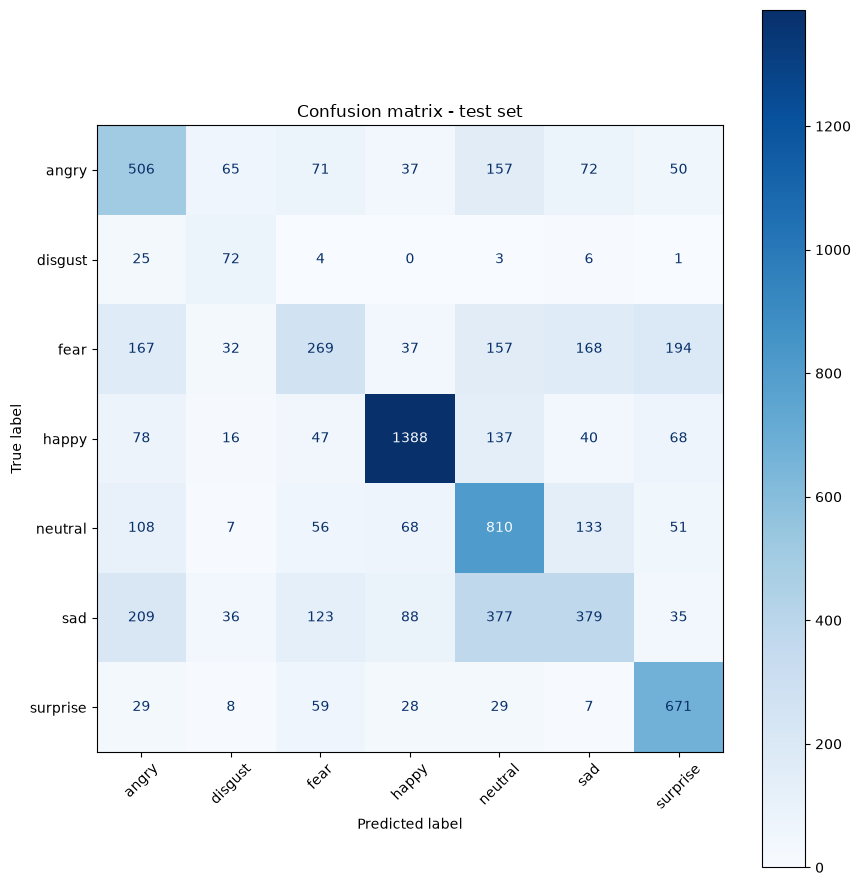

[12:29:26] Classification report CSV salvato in: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\results\tables\20260628_120337_cnn_v1_classification_report.csv
[12:29:26] Confusion matrix CSV salvata in: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\results\tables\20260628_120337_cnn_v1_confusion_matrix.csv
[12:29:26] Predizioni test salvate in: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\results\predictions\20260628_120337_cnn_v1_test_predictions.csv
[12:29:26] Confusion matrix PNG salvata in: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\results\figures\20260628_120337_cnn_v1_confusion_matrix.png
[12:29:26] FINE - Predizioni e report (3.6s)


In [5]:
import pandas as pd

with timed_step("Predizioni e report"):
    log_step("Calcolo predizioni sul test set")
    y_true = test_generator.classes
    y_pred_proba = model.predict(test_generator, verbose=1)
    y_pred = np.argmax(y_pred_proba, axis=1)

    target_names = [emotion_labels[i] for i in range(len(emotion_labels))]

    log_step("Classification report")
    class_report = classification_report(y_true, y_pred, target_names=target_names)
    class_report_dict = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        output_dict=True,
    )
    print(class_report)

    log_step("Confusion matrix")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    experiment_name = experiment_dir.name
    report_csv_path = results_tables_dir / f"{experiment_name}_classification_report.csv"
    confusion_csv_path = results_tables_dir / f"{experiment_name}_confusion_matrix.csv"
    predictions_csv_path = results_predictions_dir / f"{experiment_name}_test_predictions.csv"
    confusion_fig_path = results_figures_dir / f"{experiment_name}_confusion_matrix.png"

    pd.DataFrame(class_report_dict).transpose().to_csv(report_csv_path)
    pd.DataFrame(cm, index=target_names, columns=target_names).to_csv(confusion_csv_path)

    predictions_df = pd.DataFrame(
        {
            "filepath": test_generator.filepaths,
            "true_label": [target_names[i] for i in y_true],
            "predicted_label": [target_names[i] for i in y_pred],
        }
    )
    for class_index, class_name in enumerate(target_names):
        predictions_df[f"prob_{class_name}"] = y_pred_proba[:, class_index]
    predictions_df.to_csv(predictions_csv_path, index=False)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    fig, ax = plt.subplots(figsize=(9, 9))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    plt.title("Confusion matrix - test set")
    plt.tight_layout()
    fig.savefig(confusion_fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    log_step(f"Classification report CSV salvato in: {report_csv_path}")
    log_step(f"Confusion matrix CSV salvata in: {confusion_csv_path}")
    log_step(f"Predizioni test salvate in: {predictions_csv_path}")
    log_step(f"Confusion matrix PNG salvata in: {confusion_fig_path}")
